# Notebook 80 — state-to-endpoint reconstruction audit

This notebook isolates how `[x_sup, alpha]` becomes `fas_x_end / fas_y_end` by reusing notebook 77 outputs and mixing MATLAB vs Python sources for x, alpha, aponeurosis lines, and the fixed superficial y anchor.

In [1]:
from pathlib import Path
import subprocess
import sys
from IPython.display import Markdown, Image, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'scripts').exists():
    ROOT = ROOT.parent
SCRIPT = ROOT / 'scripts' / 'evaluate_state_to_endpoint_reconstruction.py'
OUT = ROOT / 'results' / 'notebook80_state_to_endpoint_reconstruction'
print(f'Project root: {ROOT}')
print(f'Script: {SCRIPT}')
print(f'Output directory: {OUT}')

Project root: /Users/grosbedou/PycharmProjects/NDORMS
Script: /Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_state_to_endpoint_reconstruction.py
Output directory: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook80_state_to_endpoint_reconstruction


In [2]:
completed = subprocess.run([sys.executable, str(SCRIPT)], check=True)
completed

# Notebook 80 — state-to-endpoint reconstruction audit

Aligned 2666 MATLAB/Python samples with Python offset 1.

This notebook isolates the final reconstruction layer that turns `[x_sup, alpha]` into `fas_x_end / fas_y_end`. It reuses notebook 77's saved strict Python run, then swaps MATLAB vs Python sources for x, alpha, aponeurosis lines, and fixed-y anchor while keeping the same line-intersection code.

## Main findings

- The notebook 79 baseline reproduces the current final-end gap: with Python smoothed x, Python smoothed alpha, and Python apo lines, endpoint RMSE is 5.95 px at the superficial x end and 25.80 px at the deep x end, with FL RMSE 2.0117 mm.
- Swapping only MATLAB x mostly fixes the superficial endpoint but not final FL: `end_x_sup` RMSE drops from 5.95 px to 2.35 px, while `end_x_deep` stays large at 24.58 px and FL RMSE stays 2.0124 mm.
- Swapping only MATLAB saved alpha does the opposite: `end_x_sup` stays almost unchanged at 5.91 px, but `end_x_deep` collapses fr

CompletedProcess(args=['/Users/grosbedou/PycharmProjects/NDORMS/.venv/bin/python', '/Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_state_to_endpoint_reconstruction.py'], returncode=0)

In [3]:
display(Markdown((OUT / 'notebook80_summary.md').read_text()))

# Notebook 80 — state-to-endpoint reconstruction audit

Aligned 2666 MATLAB/Python samples with Python offset 1.

This notebook isolates the final reconstruction layer that turns `[x_sup, alpha]` into `fas_x_end / fas_y_end`. It reuses notebook 77's saved strict Python run, then swaps MATLAB vs Python sources for x, alpha, aponeurosis lines, and fixed-y anchor while keeping the same line-intersection code.

## Main findings

- The notebook 79 baseline reproduces the current final-end gap: with Python smoothed x, Python smoothed alpha, and Python apo lines, endpoint RMSE is 5.95 px at the superficial x end and 25.80 px at the deep x end, with FL RMSE 2.0117 mm.
- Swapping only MATLAB x mostly fixes the superficial endpoint but not final FL: `end_x_sup` RMSE drops from 5.95 px to 2.35 px, while `end_x_deep` stays large at 24.58 px and FL RMSE stays 2.0124 mm.
- Swapping only MATLAB saved alpha does the opposite: `end_x_sup` stays almost unchanged at 5.91 px, but `end_x_deep` collapses from 25.80 px to 6.50 px and FL RMSE improves from 2.0117 mm to 0.1992 mm.
- Swapping both MATLAB x and MATLAB saved alpha on the Python apo lines brings the entire end segment close to MATLAB: `end_x_sup` RMSE 2.29 px, `end_x_deep` RMSE 2.42 px, FL RMSE 0.1989 mm.
- Replacing the Python apo lines with MATLAB's saved apo lines changes little at this layer. With MATLAB x + MATLAB saved alpha, moving from Python apo lines to MATLAB apo lines shifts `end_x_sup` RMSE only from 2.29 px to 2.43 px and `end_x_deep` RMSE only from 2.42 px to 2.41 px.
- The constant fixed-y anchor matters, but only mildly here. Using MATLAB apo lines with MATLAB x + alpha, switching the anchor from the Python frame-0 y to MATLAB's own frame-0 y changes `end_x_sup` RMSE from 2.68 px to 2.43 px.
- A crucial subtlety: MATLAB's saved `alpha` is not identical to `Fascicle.X_plus[:,1]`. Their direct difference has RMSE 0.2779 deg. That small angle delta matters geometrically: with the same MATLAB x and Python apo lines, using MATLAB `X_plus[:,1]` instead of MATLAB saved `alpha` worsens deep-end x RMSE from 2.42 px to 7.67 px.

## Interpretation

- The line-intersection math itself is mostly behaving. When fed MATLAB x and MATLAB saved alpha, it reproduces MATLAB final endpoints closely even on the Python apo lines.
- In this reconstruction layer, x mainly drives the superficial endpoint, while alpha drives the deep endpoint and almost the entire remaining FL gap.
- The dominant unresolved difference is therefore not generic apo-line geometry. It is the angle that is fed into the final endpoint reconstruction.

## Audit cross-check

- I do not see evidence of a more important missing geometric function than this endpoint-angle issue.
- The next thing that needs direct attention is MATLAB's exact final-angle path into `fas_x_end / fas_y_end`: whether that angle is a post-filter/post-smoother output convention, or logic adjacent to fields like `Fascicle.A`.
- `Fascicle.A` stays on the checklist, but notebook 80 moves it from a vague possibility to a targeted question about how MATLAB derives the final angle used for endpoint reconstruction.

- Variant CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook80_state_to_endpoint_reconstruction/endpoint_reconstruction_variants.csv`
- Input delta CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook80_state_to_endpoint_reconstruction/input_signal_deltas.csv`
- Plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook80_state_to_endpoint_reconstruction/endpoint_reconstruction_variants.png`


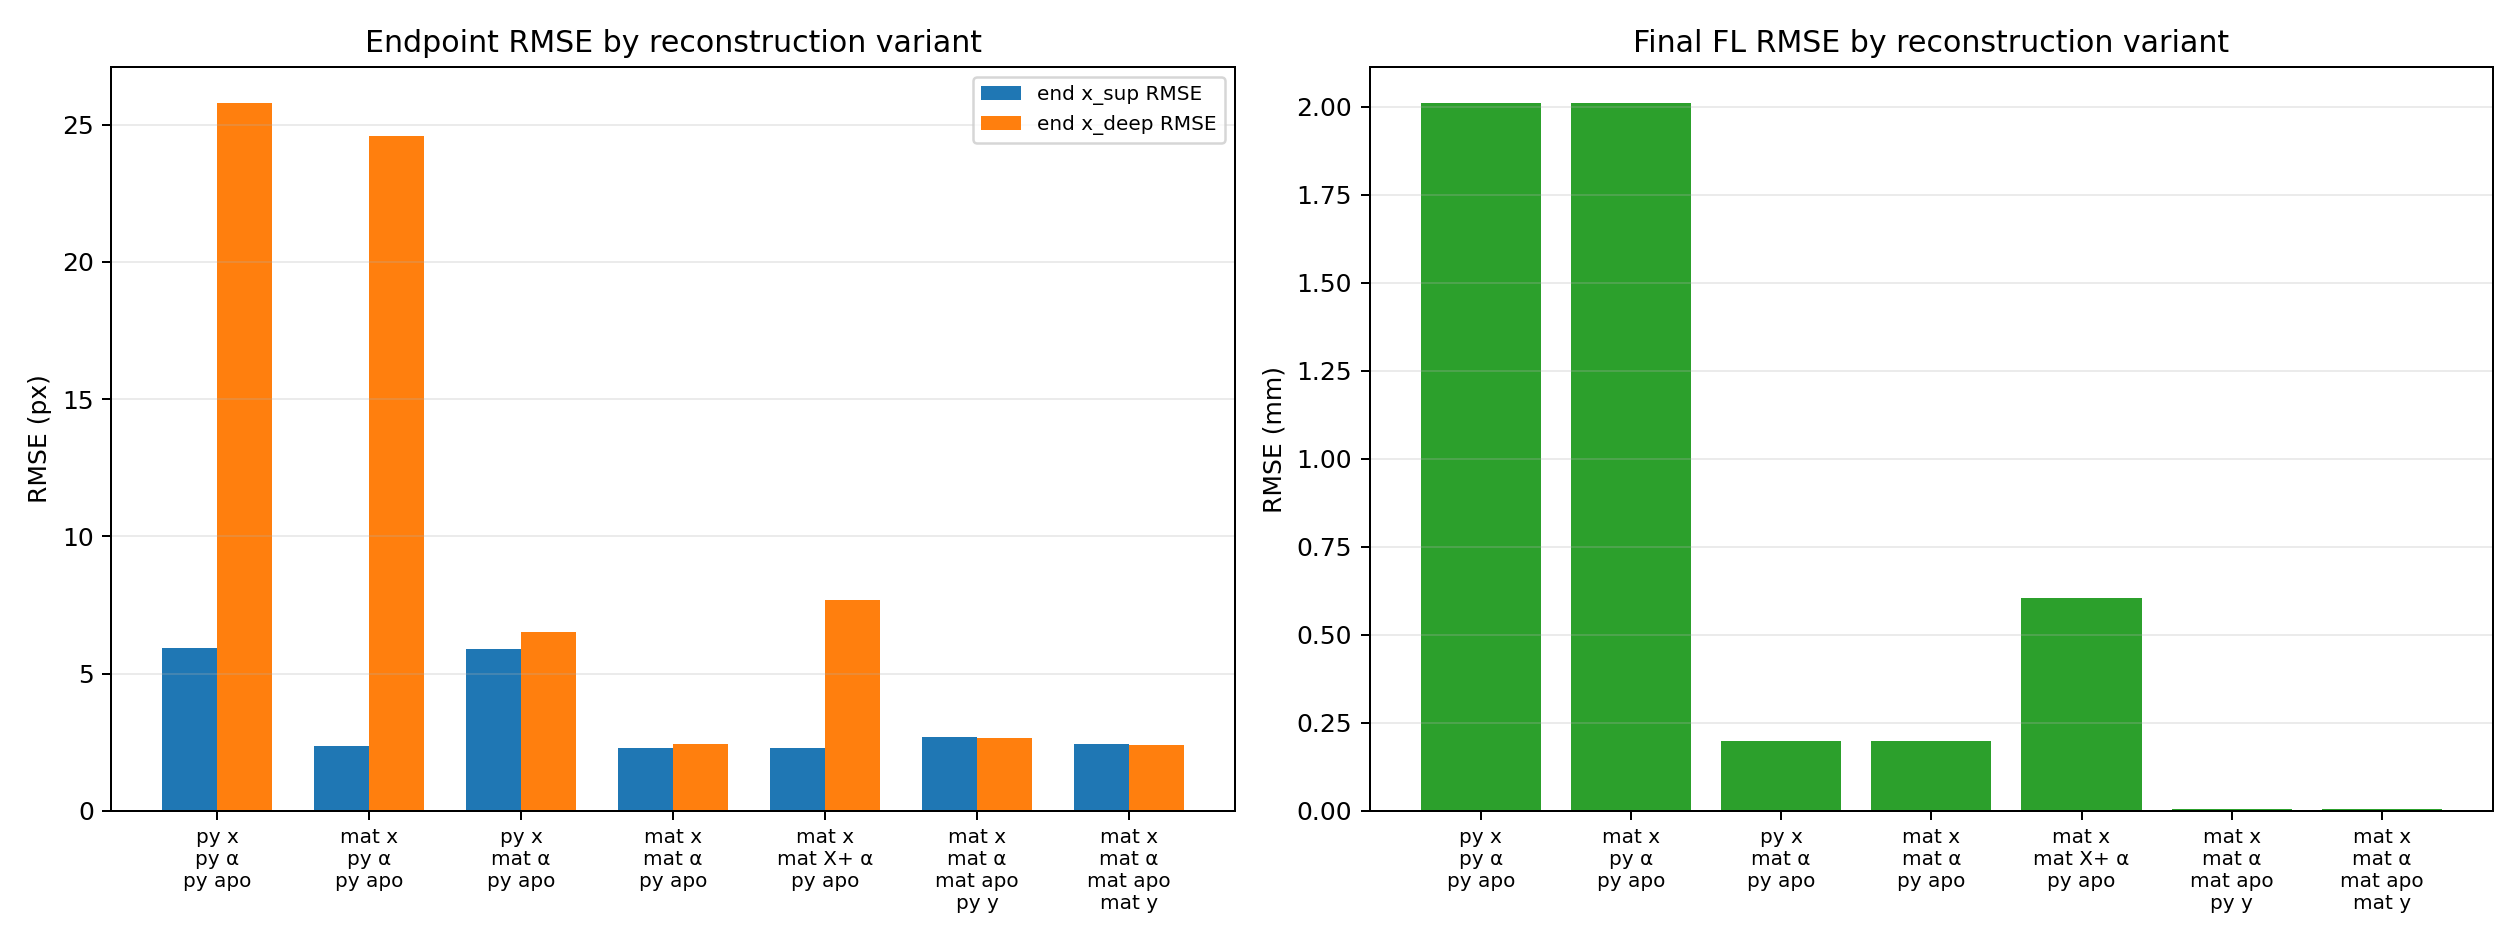

In [4]:
display(Image(filename=str(OUT / 'endpoint_reconstruction_variants.png')))